# Family Selector and Projected QP Validation Tutorial

This notebook checks two package design promises:

1. SILVA implementations can be selected by family name.
2. The projected quadratic-program layer solves real constrained fixed-point
   problems with gradients.

The shared equilibrium contract is

$$
z^\star=f_\theta(z^\star,x),
\qquad
r(z^\star,x)=f_\theta(z^\star,x)-z^\star.
$$

For the projected QP case, the state is an optimizer variable:

$$
z_i^\star
=
\arg\min_{z\in C}
\frac12 z^\top A z-b_i^\top z,
\qquad
A=L L^\top+\lambda I.
$$

The fixed-point map is

$$
T(z)=\Pi_C[z-\eta(Az-b_i)].
$$

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import (
    SILVADEQFlow,
    SILVAProjectedQPLayer,
    SolverConfig,
    available_silva_families,
    make_silva_translation_flow_batch,
    resolve_device,
    silva_deq_flow,
    silva_endpoint_error,
    silva_equilibrium_model,
    silva_family_description,
    silva_projected_qp_layer,
)

torch.manual_seed(9)
device = resolve_device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Selectable Families

The canonical public names favor SILVA-style entry points. Compatibility aliases
such as `"optical_flow_deq"` and `"constrained_quadratic_optimization"` still
resolve to the same package-native implementations.

In [3]:
for name in available_silva_families():
    print(f"{name:28s} -> {silva_family_description(name)}")

silva_layer                  -> single generalized SILVA layer with user-selected branches
silva_graph                  -> stacked SILVA graph model with per-layer operators and solvers
silva_graph_preset           -> reference graph SILVA architecture with configurable interaction modes
silva_cortex                 -> single flexible cortex-style equilibrium point with internal modules
silva_image_cortex           -> convolutional-retina plus linked fast/slow cortex equilibrium points
compact_deq                  -> affine-tanh DEQ reduction inside the SILVA grammar
message_passing_deq          -> local graph/message-passing DEQ reduction
mdeq                         -> compact multiscale DEQ bridge block
multiscale_vision_deq        -> simultaneous multiresolution MDEQ image core
sequence_deq                 -> weight-shared relative-attention or trellis sequence equilibrium
implicit_graph               -> IGNN graph equilibrium with configurable adjacency normalization
implicit_neur

In [4]:
flow_from_alias = silva_equilibrium_model(
    "optical_flow_deq",
    feature_dim=2,
    hidden_dim=4,
    config=SolverConfig(solver="picard", max_iter=1, alpha=0.4),
)
qp_from_alias = silva_equilibrium_model(
    "constrained_quadratic_optimization",
    in_dim=3,
    state_dim=4,
    constraint="simplex",
    config=SolverConfig(solver="picard", max_iter=3, alpha=1.0),
)

isinstance(flow_from_alias, SILVADEQFlow), isinstance(qp_from_alias, SILVAProjectedQPLayer)

(True, True)

## Simplex Projection

The simplex constraint is

$$
\Delta_m=\{z\in\mathbb R^d:z_j\ge 0,\ \sum_jz_j=m\}.
$$

After the solve, every row should be nonnegative and should sum to `m`.

In [5]:
x = torch.randn(8, 3, device=device)
simplex_layer = silva_projected_qp_layer(
    in_dim=3,
    state_dim=4,
    constraint="simplex",
    simplex_mass=1.0,
    step_size=0.08,
    config=SolverConfig(solver="picard", max_iter=30, alpha=1.0, tol=1e-7),
).to(device)

simplex_result = simplex_layer(x, return_result=True)
simplex_energy = simplex_layer.energy(simplex_result.z, x).mean()
simplex_energy.backward()

print("shape:", tuple(simplex_result.z.shape))
print("row sums:", simplex_result.z.sum(dim=-1).detach().cpu().round(decimals=6).tolist())
print("minimum entry:", float(simplex_result.z.min().detach().cpu()))
print("projected residual:", simplex_result.residual)
print("gradient reached B:", simplex_layer.b_proj.weight.grad is not None)

shape: (8, 4)
row sums: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
minimum entry: 0.0
projected residual: 0.00085169926751405
gradient reached B: True


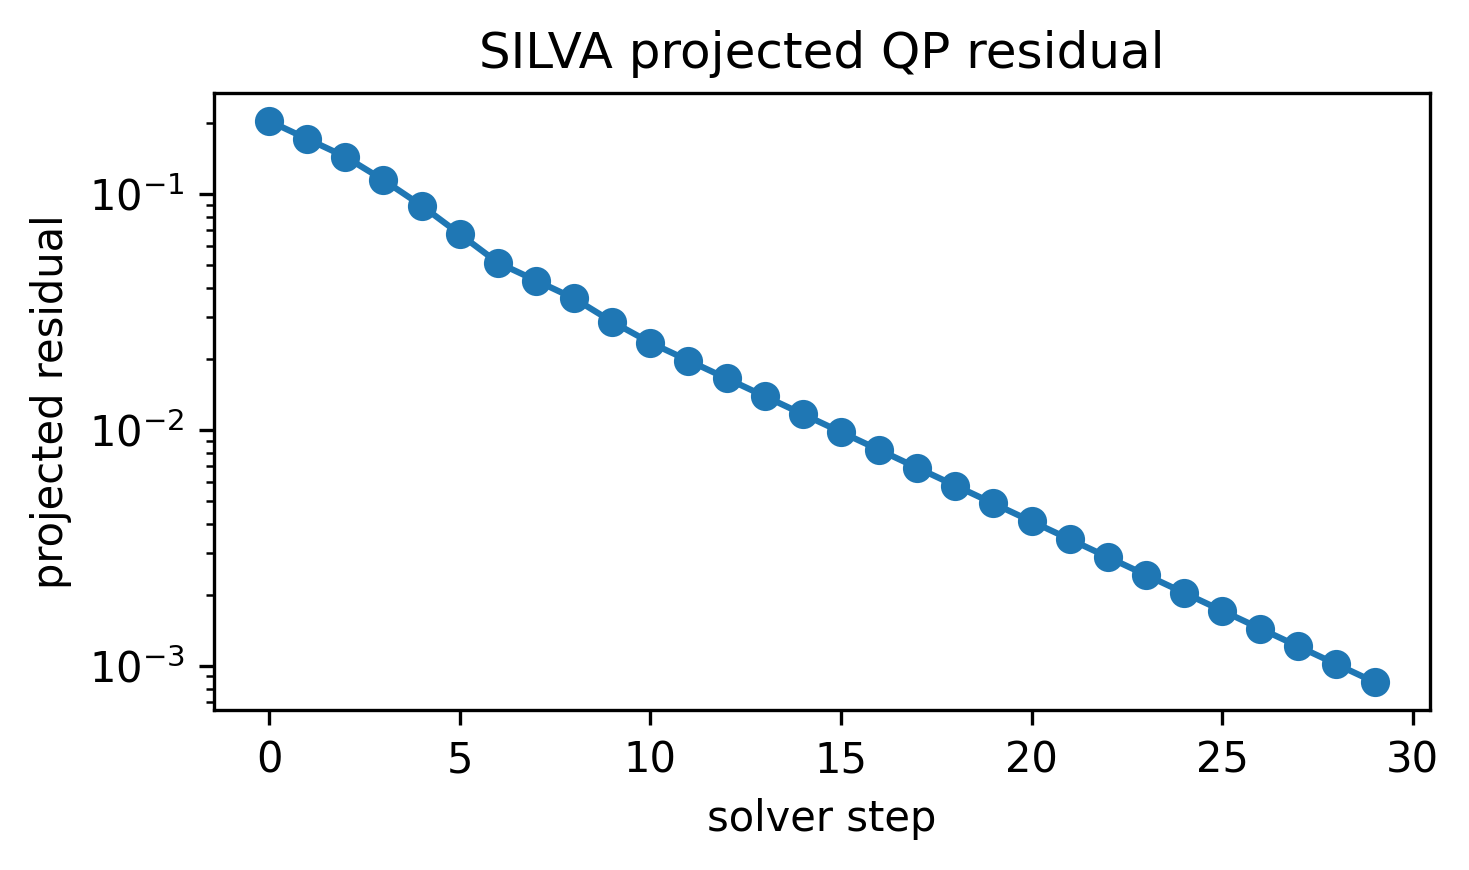

In [6]:
plt.figure(figsize=(5, 3))
plt.plot(simplex_result.residuals, marker="o")
plt.yscale("log")
plt.xlabel("solver step")
plt.ylabel("projected residual")
plt.title("SILVA projected QP residual")
plt.tight_layout()

## Box and Affine Constraints

For a box,

$$
C=[\ell,u]^d.
$$

For an affine equality,

$$
C=\{z:A_{\rm eq}z=b_{\rm eq}\}.
$$

The validation checks below verify the constraints directly from the returned
states.

In [7]:
box_layer = silva_projected_qp_layer(
    in_dim=3,
    state_dim=5,
    constraint="box",
    lower_bound=-0.25,
    upper_bound=0.25,
    step_size=0.08,
    config=SolverConfig(solver="picard", max_iter=20, alpha=1.0),
).to(device)
z_box = box_layer(x)
print(float(z_box.min().detach().cpu()), float(z_box.max().detach().cpu()))

Aeq = torch.tensor([[1.0, 1.0, 0.0]], device=device)
beq = torch.tensor([1.0], device=device)
affine_layer = silva_projected_qp_layer(
    in_dim=3,
    state_dim=3,
    constraint="affine",
    equality_matrix=Aeq,
    equality_rhs=beq,
    step_size=0.08,
    config=SolverConfig(solver="picard", max_iter=20, alpha=1.0),
).to(device)
z_affine = affine_layer(x)
print((z_affine @ Aeq.T).detach().cpu().round(decimals=6).tolist())

-0.25 0.25
[[1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1.0]]


## Flow Family Validation Check

The flow model has a different state shape, but the same solver pattern:

$$
u^\star=T_\theta(u^\star,I_1,I_2).
$$

The package-native `silva_deq_flow` name keeps the SILVA convention, while the
documentation cites RAFT for all-pairs correlation and DEQ-Flow for the
equilibrium optical-flow framing.

In [8]:
batch = make_silva_translation_flow_batch(batch_size=1, height=6, width=6, device=device)
flow_model = silva_deq_flow(
    feature_dim=2,
    hidden_dim=4,
    config=SolverConfig(solver="picard", max_iter=2, alpha=0.4),
).to(device)
flow_result = flow_model(batch.image1, batch.image2, return_result=True)
epe = silva_endpoint_error(flow_result.flow, batch.flow, batch.valid)
print(tuple(flow_result.flow.shape), float(epe.detach().cpu()), flow_result.solver_result.residual)

(1, 2, 6, 6) 1.0169347524642944 0.29829278588294983


## Citation

If this notebook or package is used, cite:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.0.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770099
```

When the work is connected to the SILVA Networks paper, cite the paper as well.

Additional method citations:

- Deep Equilibrium Models: https://arxiv.org/abs/1909.01377
- TorchDEQ: https://github.com/locuslab/torchdeq
- RAFT: https://arxiv.org/abs/2003.12039
- Deep Equilibrium Optical Flow Estimation: https://arxiv.org/abs/2204.08442
- OptNet: https://arxiv.org/abs/1703.00443
- Differentiable Convex Optimization Layers: https://arxiv.org/abs/1910.12430
- CVXPYlayers: https://github.com/cvxpy/cvxpylayers